Epoch [10/100], Loss: 0.2158
Epoch [20/100], Loss: 0.0585
Epoch [30/100], Loss: 0.0540
Epoch [40/100], Loss: 0.0505
Epoch [50/100], Loss: 0.0472
Epoch [60/100], Loss: 0.0441
Epoch [70/100], Loss: 0.0412
Epoch [80/100], Loss: 0.0385
Epoch [90/100], Loss: 0.0360
Epoch [100/100], Loss: 0.0336


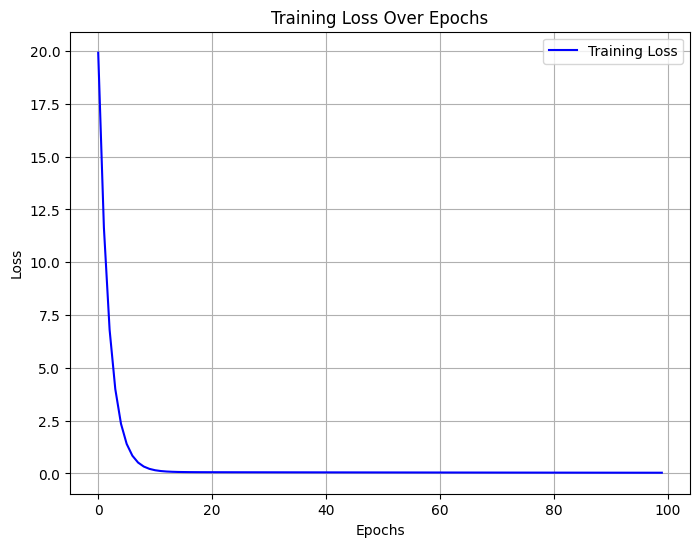

Predicted next value: 15.4791


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define a simple PyTorch model
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

# Define a helper class for training and evaluation with tracking of loss
class SequencePredictor:
    def __init__(self, model, criterion, optimizer):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_losses = []  # To store training losses

    def train(self, x_train, y_train, num_epochs=100):
        for epoch in range(num_epochs):
            self.model.train()
            self.optimizer.zero_grad()

            outputs = self.model(x_train)
            loss = self.criterion(outputs, y_train)

            loss.backward()
            self.optimizer.step()

            # Store loss for plotting
            self.train_losses.append(loss.item())

            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

    def predict(self, x):
        self.model.eval()
        with torch.no_grad():
            return self.model(x)

# Plotting the Loss
def plot_loss(losses):
    plt.figure(figsize=(8, 6))
    plt.plot(losses, label='Training Loss', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

# Generate dummy data for training
x_data = torch.tensor([[1], [2], [3], [4], [5]], dtype=torch.float32)
y_data = torch.tensor([[2], [4], [6], [8], [10]], dtype=torch.float32)

# Initialize model, loss function, and optimizer
model = SimpleModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Instantiate the predictor and train the model
predictor = SequencePredictor(model, criterion, optimizer)
predictor.train(x_data, y_data, num_epochs=100)

# Plot the loss after training
plot_loss(predictor.train_losses)

# Test the model
test_input = torch.tensor([[8]], dtype=torch.float32)  # Testing a single value
predicted_output = predictor.predict(test_input)
print(f"Predicted next value: {predicted_output.item():.4f}")
